# 02 - Text Embedding Dataset and Linear Sanity Baseline

## Objective

The first notebook explored how CLIP maps images and text into a shared embedding space.

This notebook begins the Mini-NOVIC implementation.

The main goal is to create a small training dataset of:

caption → object noun

and convert each caption into a frozen CLIP text embedding.

The pipeline is:

caption
↓
frozen CLIP text encoder
↓
L2-normalized embedding
↓
object noun target

We will:

1. Define a small object-noun vocabulary.
2. Generate many captions for every noun.
3. Create train/validation splits.
4. Load the same frozen CLIP model used previously.
5. Encode all captions into CLIP text embeddings.
6. L2-normalize the embeddings.
7. Cache the embeddings to Google Drive.
8. Reload and verify the cache.
9. Train a simple linear classifier from embedding → noun ID.
10. Evaluate validation accuracy and inspect mistakes.

The linear classifier is only a sanity check.

The final NOVIC-style system will later replace this classifier with an
autoregressive Transformer decoder capable of generating object nouns as text.

## 1. Environment setup

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


## 2. Persistent cloud storage

Large generated files such as datasets, embeddings and future checkpoints are
stored in Google Drive rather than GitHub.

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/mini_novic_storage"
)

DATASET_DIR = DRIVE_ROOT / "datasets" / "text_embedding_dataset"
EMBEDDING_DIR = DRIVE_ROOT / "embeddings" / "text_embedding_dataset"
RESULT_DIR = DRIVE_ROOT / "results" / "text_embedding_dataset"

for directory in [
    DATASET_DIR,
    EMBEDDING_DIR,
    RESULT_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Dataset directory :", DATASET_DIR)
print("Embedding directory:", EMBEDDING_DIR)
print("Result directory   :", RESULT_DIR)

Dataset directory : /content/drive/MyDrive/mini_novic_storage/datasets/text_embedding_dataset
Embedding directory: /content/drive/MyDrive/mini_novic_storage/embeddings/text_embedding_dataset
Result directory   : /content/drive/MyDrive/mini_novic_storage/results/text_embedding_dataset


Install/import OpenCLIP

In [5]:
!pip install -q open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00


In [6]:
import open_clip

print("OpenCLIP imported successfully")

OpenCLIP imported successfully


## 3. Object noun vocabulary

We begin with a small controlled vocabulary of visually concrete objects.

The target noun is stored in a canonical form.

Some multi-word nouns are deliberately included because the later autoregressive
decoder must learn to generate more than one token.

In [7]:
nouns = [
    "dog",
    "cat",
    "bird",
    "horse",
    "elephant",
    "cow",
    "sheep",
    "bear",
    "zebra",
    "giraffe",

    "car",
    "bus",
    "truck",
    "bicycle",
    "motorcycle",
    "airplane",
    "helicopter",
    "boat",
    "train",
    "sports car",

    "chair",
    "table",
    "bed",
    "sofa",
    "bottle",
    "cup",
    "book",
    "clock",
    "backpack",
    "umbrella",

    "laptop",
    "keyboard",
    "mouse",
    "phone",
    "television",
    "camera",
    "headphones",
    "printer",
    "monitor",
    "calculator",

    "fire truck",
    "traffic light",
    "coffee mug",
    "tennis racket",
    "baseball bat",
    "parking meter",
    "street sign",
    "water bottle",
    "office chair",
    "dining table",
]

print("Number of nouns:", len(nouns))

Number of nouns: 50


Create stable noun IDs

In [8]:
noun_to_id = {
    noun: idx
    for idx, noun in enumerate(nouns)
}

id_to_noun = {
    idx: noun
    for noun, idx in noun_to_id.items()
}

for noun in nouns[:10]:
    print(
        noun_to_id[noun],
        "→",
        noun
    )

0 → dog
1 → cat
2 → bird
3 → horse
4 → elephant
5 → cow
6 → sheep
7 → bear
8 → zebra
9 → giraffe


### Article helper

In [9]:
def article_for(noun):
    first_letter = noun.strip()[0].lower()

    if first_letter in "aeiou":
        return "an"

    return "a"

In [10]:
for noun in [
    "dog",
    "airplane",
    "elephant",
    "office chair"
]:
    print(
        article_for(noun),
        noun
    )

a dog
an airplane
an elephant
an office chair


## 4. Caption generation

NOVIC is trained from text-derived embeddings rather than image labels.

We therefore generate many natural descriptions for each target noun.

The noun remains semantically central while the surrounding text changes.

In [11]:
caption_templates = [
    "a photo of {article} {noun}",
    "a photograph of {article} {noun}",
    "an image of {article} {noun}",
    "a picture of {article} {noun}",
    "a clear photo of {article} {noun}",
    "a close-up photo of {article} {noun}",
    "a detailed photo of {article} {noun}",
    "a cropped photo of {article} {noun}",
    "a bright photo of {article} {noun}",
    "a dark photo of {article} {noun}",

    "{article_cap} {noun} in the scene",
    "{article_cap} {noun} visible in the image",
    "{article_cap} {noun} shown clearly",
    "{article_cap} {noun} in a photograph",
    "{article_cap} {noun} in the picture",
    "{article_cap} {noun} near the center of the image",
    "{article_cap} {noun} viewed from the front",
    "{article_cap} {noun} viewed from the side",
    "{article_cap} {noun} viewed from a distance",
    "{article_cap} {noun} seen nearby",

    "the image contains {article} {noun}",
    "the photo contains {article} {noun}",
    "the picture contains {article} {noun}",
    "the main object is {article} {noun}",
    "the visible object is {article} {noun}",
    "the central object is {article} {noun}",
    "the scene includes {article} {noun}",
    "this scene contains {article} {noun}",
    "this photograph shows {article} {noun}",
    "this image shows {article} {noun}",

    "there is {article} {noun} in the image",
    "there is {article} {noun} in the photo",
    "there is {article} {noun} in the scene",
    "we can see {article} {noun}",
    "one can see {article} {noun}",
    "the photograph features {article} {noun}",
    "the image features {article} {noun}",
    "the picture features {article} {noun}",
    "the scene features {article} {noun}",
    "the object shown is {article} {noun}",

    "a realistic image of {article} {noun}",
    "a natural image of {article} {noun}",
    "a simple image of {article} {noun}",
    "a high-quality photo of {article} {noun}",
    "a photograph containing {article} {noun}",
    "a scene containing {article} {noun}",
    "an everyday view of {article} {noun}",
    "an example of {article} {noun}",
    "a visual example of {article} {noun}",
    "a recognizable {noun}",
]

print("Number of templates:", len(caption_templates))

Number of templates: 50


## Generate the complete dataset

In [12]:
records = []

for noun in nouns:

    noun_id = noun_to_id[noun]

    article = article_for(noun)

    for template_id, template in enumerate(
        caption_templates
    ):

        caption = template.format(
            noun=noun,
            article=article,
            article_cap=article.capitalize()
        )

        records.append({
            "noun_id": noun_id,
            "noun_text": noun,
            "template_id": template_id,
            "caption": caption
        })

dataset_df = pd.DataFrame(records)

dataset_df.head(10)

,noun_id,noun_text,template_id,caption
0,0,dog,0,a photo of a dog
1,0,dog,1,a photograph of a dog
2,0,dog,2,an image of a dog
3,0,dog,3,a picture of a dog
4,0,dog,4,a clear photo of a dog
5,0,dog,5,a close-up photo of a dog
6,0,dog,6,a detailed photo of a dog
7,0,dog,7,a cropped photo of a dog
8,0,dog,8,a bright photo of a dog
9,0,dog,9,a dark photo of a dog


In [13]:
print("Number of examples:", len(dataset_df))
print("Number of nouns:", dataset_df["noun_text"].nunique())
print(
    "Captions per noun:",
    len(dataset_df) //
    dataset_df["noun_text"].nunique()
)

Number of examples: 2500
Number of nouns: 50
Captions per noun: 50


### Inspect random samples

In [14]:
dataset_df.sample(
    15,
    random_state=SEED
)

,noun_id,noun_text,template_id,caption
1447,28,backpack,47,an example of a backpack
1114,22,bed,14,A bed in the picture
1064,21,table,14,A table in the picture
2287,45,parking meter,37,the picture features a parking meter
1537,30,laptop,37,the picture features a laptop
668,13,bicycle,18,A bicycle viewed from a distance
1583,31,keyboard,33,we can see a keyboard
2404,48,office chair,4,a clear photo of an office chair
497,9,giraffe,47,an example of a giraffe
2480,49,dining table,30,there is a dining table in the image


### Check duplicates

In [15]:
num_duplicates = dataset_df[
    "caption"
].duplicated().sum()

print(
    "Duplicate captions:",
    num_duplicates
)

Duplicate captions: 0


In [16]:
print(
    dataset_df.groupby(
        "noun_text"
    ).size().describe()
)

count    50.0
mean     50.0
std       0.0
min      50.0
25%      50.0
50%      50.0
75%      50.0
max      50.0
dtype: float64


## 5. Train-validation split

The first experiment uses caption-level splitting.

Every noun appears in both training and validation sets, but the exact captions
are separated.

This evaluates whether the model generalizes across different descriptions of
the same object concept.

In [17]:
from sklearn.model_selection import train_test_split

train_indices = []
val_indices = []

for noun_id in sorted(
    dataset_df["noun_id"].unique()
):

    noun_rows = dataset_df[
        dataset_df["noun_id"] == noun_id
    ].index

    train_idx, val_idx = train_test_split(
        noun_rows,
        test_size=0.20,
        random_state=SEED
    )

    train_indices.extend(train_idx)
    val_indices.extend(val_idx)

Assign:

In [18]:
dataset_df["split"] = "train"

dataset_df.loc[
    val_indices,
    "split"
] = "val"

Inspect:

In [19]:
print(
    dataset_df["split"].value_counts()
)

split
train    2000
val       500
Name: count, dtype: int64


Check each noun:

In [20]:
split_table = pd.crosstab(
    dataset_df["noun_text"],
    dataset_df["split"]
)

split_table.head(10)

split,train,val
noun_text,,
airplane,40,10
backpack,40,10
baseball bat,40,10
bear,40,10
bed,40,10
bicycle,40,10
bird,40,10
boat,40,10
book,40,10


### Save the caption dataset to Drive

In [21]:
dataset_path = (
    DATASET_DIR /
    "mini_novic_captions.csv"
)

dataset_df.to_csv(
    dataset_path,
    index=False
)

print("Saved to:")
print(dataset_path)

Saved to:
/content/drive/MyDrive/mini_novic_storage/datasets/text_embedding_dataset/mini_novic_captions.csv


## 6. Load the frozen CLIP text encoder

The CLIP model is not trained or modified.

It is used only to convert each caption into a semantic text embedding.

In [22]:
MODEL_NAME = "ViT-B-32"
PRETRAINED = "laion2b_s34b_b79k"

model, _, preprocess = (
    open_clip.create_model_and_transforms(
        MODEL_NAME,
        pretrained=PRETRAINED
    )
)

tokenizer = open_clip.get_tokenizer(
    MODEL_NAME
)

model = model.to(device)
model.eval()

print("Model:", MODEL_NAME)
print("Weights:", PRETRAINED)

open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

Model: ViT-B-32
Weights: laion2b_s34b_b79k


In [23]:
for parameter in model.parameters():
    parameter.requires_grad = False

Verification

In [24]:
trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Trainable CLIP parameters:",
    trainable_parameters
)

Trainable CLIP parameters: 0


## Encode one caption first
Before processing all 2500 captions, test one.

In [25]:
sample_caption = dataset_df.iloc[0]["caption"]

print(
    "Caption:",
    sample_caption
)

Caption: a photo of a dog


Tokenize:

In [26]:
sample_tokens = tokenizer(
    [sample_caption]
).to(device)

print(
    "Token shape:",
    sample_tokens.shape
)

Token shape: torch.Size([1, 77])


Encode:

In [27]:
with torch.no_grad():

    sample_embedding = (
        model.encode_text(
            sample_tokens
        )
    )

print(
    "Embedding shape:",
    sample_embedding.shape
)

Embedding shape: torch.Size([1, 512])


Normalize:

In [28]:
sample_embedding = F.normalize(
    sample_embedding,
    dim=-1
)

print(
    "Embedding norm:",
    sample_embedding.norm(
        dim=-1
    )
)

Embedding norm: tensor([1.0000], device='cuda:0')


## Batch encoding function

In [29]:
def encode_captions(
    captions,
    batch_size=128
):

    all_embeddings = []

    for start in range(
        0,
        len(captions),
        batch_size
    ):

        batch_captions = captions[
            start:start + batch_size
        ]

        tokens = tokenizer(
            batch_captions
        ).to(device)

        with torch.no_grad():

            embeddings = (
                model.encode_text(tokens)
            )

            embeddings = F.normalize(
                embeddings,
                dim=-1
            )

        all_embeddings.append(
            embeddings.cpu()
        )

    return torch.cat(
        all_embeddings,
        dim=0
    )

## Encode the entire dataset

In [30]:
all_captions = (
    dataset_df["caption"]
    .tolist()
)

text_embeddings = encode_captions(
    all_captions,
    batch_size=128
)

print(
    "Embedding matrix shape:",
    text_embeddings.shape
)

Embedding matrix shape: torch.Size([2500, 512])


## Verify every embedding norm

In [31]:
embedding_norms = (
    text_embeddings.norm(
        dim=-1
    )
)

print(
    "Minimum norm:",
    embedding_norms.min().item()
)

print(
    "Maximum norm:",
    embedding_norms.max().item()
)

print(
    "Mean norm:",
    embedding_norms.mean().item()
)

Minimum norm: 0.9999997615814209
Maximum norm: 1.000000238418579
Mean norm: 1.0


In [32]:
assert torch.allclose(
    embedding_norms,
    torch.ones_like(
        embedding_norms
    ),
    atol=1e-4
)

print(
    "All embeddings are L2 normalized."
)

All embeddings are L2 normalized.


## Create target tensor


In [33]:
targets = torch.tensor(
    dataset_df["noun_id"].values,
    dtype=torch.long
)

print(
    "Targets shape:",
    targets.shape
)

print(
    "First 10 targets:",
    targets[:10]
)

Targets shape: torch.Size([2500])
First 10 targets: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


## Cache embeddings to Google Drive
This step is very important.

We do not want to execute CLIP every time we train the Mini-NOVIC decoder.

That is exactly why the roadmap recommends precomputing and caching the embeddings.

In [34]:
embedding_cache_path = (
    EMBEDDING_DIR /
    "clip_text_embeddings.pt"
)

torch.save(
    {
        "embeddings": text_embeddings,
        "targets": targets,
        "captions": dataset_df["caption"].tolist(),
        "noun_text": dataset_df["noun_text"].tolist(),
        "split": dataset_df["split"].tolist(),

        "model_name": MODEL_NAME,
        "pretrained": PRETRAINED,
        "seed": SEED,
    },
    embedding_cache_path
)

print(
    "Embedding cache saved:"
)

print(
    embedding_cache_path
)

Embedding cache saved:
/content/drive/MyDrive/mini_novic_storage/embeddings/text_embedding_dataset/clip_text_embeddings.pt


## Check cache size

In [35]:
import os

cache_size_mb = (
    os.path.getsize(
        embedding_cache_path
    )
    / 1024**2
)

print(
    f"Cache size: {cache_size_mb:.2f} MB"
)

Cache size: 5.02 MB


## Reload the cache
Never trust a cache until we prove we can load it.

In [36]:
cache = torch.load(
    embedding_cache_path,
    map_location="cpu"
)

cached_embeddings = (
    cache["embeddings"]
)

cached_targets = (
    cache["targets"]
)

print(
    cached_embeddings.shape
)

print(
    cached_targets.shape
)

torch.Size([2500, 512])
torch.Size([2500])


Check equality:

In [37]:
print(
    "Embeddings identical:",
    torch.equal(
        text_embeddings,
        cached_embeddings
    )
)

print(
    "Targets identical:",
    torch.equal(
        targets,
        cached_targets
    )
)

Embeddings identical: True
Targets identical: True


## Create train and validation tensors

In [38]:
train_mask = torch.tensor(
    (
        dataset_df["split"]
        == "train"
    ).values
)

val_mask = torch.tensor(
    (
        dataset_df["split"]
        == "val"
    ).values
)

X_train = text_embeddings[
    train_mask
]

y_train = targets[
    train_mask
]

X_val = text_embeddings[
    val_mask
]

y_val = targets[
    val_mask
]

print(
    "Training:",
    X_train.shape,
    y_train.shape
)

print(
    "Validation:",
    X_val.shape,
    y_val.shape
)

Training: torch.Size([2000, 512]) torch.Size([2000])
Validation: torch.Size([500, 512]) torch.Size([500])


## 7. Linear noun classifier sanity check

Before implementing an autoregressive Transformer, we verify that the cached CLIP
embeddings and noun labels are correctly aligned.

A single linear layer maps the 512-dimensional CLIP embedding to the 50 noun classes.

This classifier is NOT the final Mini-NOVIC decoder.

It is only a debugging baseline.

In [39]:
embedding_dim = X_train.shape[1]
num_classes = len(nouns)

classifier = nn.Linear(
    embedding_dim,
    num_classes
).to(device)

print(classifier)

Linear(in_features=512, out_features=50, bias=True)


In [40]:
from torch.utils.data import (
    TensorDataset,
    DataLoader
)

train_dataset = TensorDataset(
    X_train,
    y_train
)

val_dataset = TensorDataset(
    X_val,
    y_val
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)

### Loss and optimizer

In [41]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    classifier.parameters(),
    lr=1e-3
)

### Training loop

In [42]:
NUM_EPOCHS = 20

train_losses = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):

    # -------------------------
    # Training
    # -------------------------

    classifier.train()

    total_loss = 0.0

    for batch_X, batch_y in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = classifier(
            batch_X
        )

        loss = criterion(
            logits,
            batch_y
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * batch_X.size(0)
        )

    average_loss = (
        total_loss
        / len(train_dataset)
    )

    train_losses.append(
        average_loss
    )

    # -------------------------
    # Validation
    # -------------------------

    classifier.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for batch_X, batch_y in val_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            logits = classifier(
                batch_X
            )

            predictions = (
                logits.argmax(
                    dim=1
                )
            )

            correct += (
                predictions
                == batch_y
            ).sum().item()

            total += batch_y.size(0)

    val_accuracy = (
        correct / total
    )

    val_accuracies.append(
        val_accuracy
    )

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Loss: {average_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch 01/20 | Loss: 3.8300 | Val Accuracy: 0.9460
Epoch 02/20 | Loss: 3.6580 | Val Accuracy: 0.9960
Epoch 03/20 | Loss: 3.4919 | Val Accuracy: 1.0000
Epoch 04/20 | Loss: 3.3273 | Val Accuracy: 1.0000
Epoch 05/20 | Loss: 3.1658 | Val Accuracy: 1.0000
Epoch 06/20 | Loss: 3.0073 | Val Accuracy: 1.0000
Epoch 07/20 | Loss: 2.8513 | Val Accuracy: 1.0000
Epoch 08/20 | Loss: 2.6992 | Val Accuracy: 1.0000
Epoch 09/20 | Loss: 2.5512 | Val Accuracy: 1.0000
Epoch 10/20 | Loss: 2.4074 | Val Accuracy: 1.0000
Epoch 11/20 | Loss: 2.2676 | Val Accuracy: 1.0000
Epoch 12/20 | Loss: 2.1320 | Val Accuracy: 1.0000
Epoch 13/20 | Loss: 2.0027 | Val Accuracy: 1.0000
Epoch 14/20 | Loss: 1.8781 | Val Accuracy: 1.0000
Epoch 15/20 | Loss: 1.7587 | Val Accuracy: 1.0000
Epoch 16/20 | Loss: 1.6457 | Val Accuracy: 1.0000
Epoch 17/20 | Loss: 1.5385 | Val Accuracy: 1.0000
Epoch 18/20 | Loss: 1.4373 | Val Accuracy: 1.0000
Epoch 19/20 | Loss: 1.3419 | Val Accuracy: 1.0000
Epoch 20/20 | Loss: 1.2526 | Val Accuracy: 1.0000


### Training curves

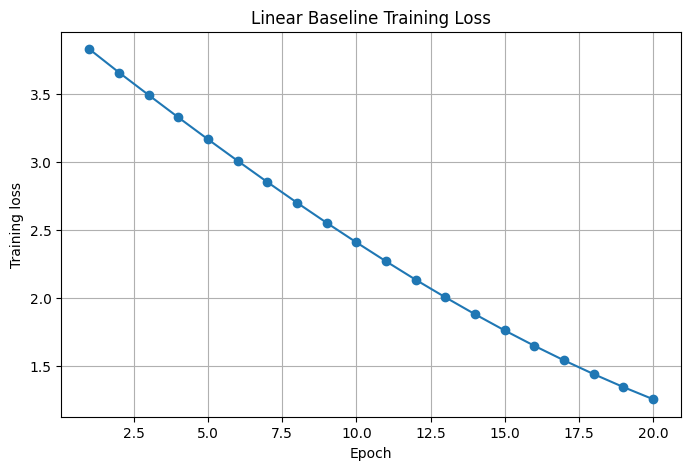

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Linear Baseline Training Loss")
plt.grid(True)

plt.show()

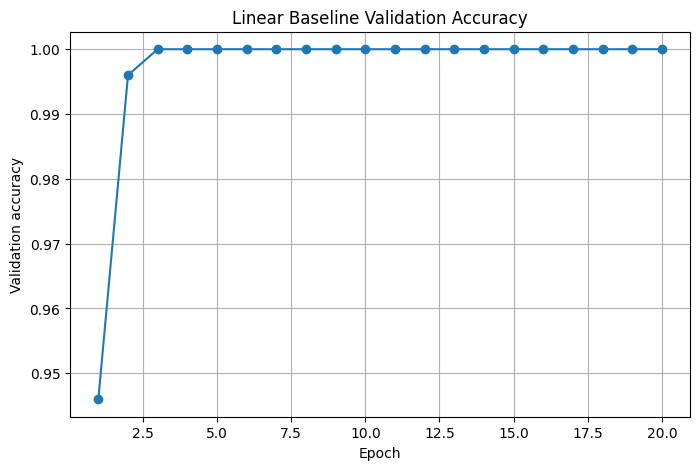

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    val_accuracies,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Linear Baseline Validation Accuracy")
plt.grid(True)

plt.show()

## Final validation predictions

In [45]:
classifier.eval()

all_predictions = []

with torch.no_grad():

    logits = classifier(
        X_val.to(device)
    )

    predictions = logits.argmax(
        dim=1
    )

    all_predictions = (
        predictions
        .cpu()
    )

In [46]:
accuracy = (
    all_predictions
    == y_val
).float().mean().item()

print(
    f"Final validation accuracy: "
    f"{accuracy:.4f}"
)

Final validation accuracy: 1.0000


## Inspect actual predictions

In [47]:
val_df = (
    dataset_df[
        dataset_df["split"] == "val"
    ]
    .copy()
    .reset_index(drop=True)
)

val_df[
    "predicted_id"
] = all_predictions.numpy()

val_df[
    "predicted_noun"
] = val_df[
    "predicted_id"
].map(id_to_noun)

val_df[
    "correct"
] = (
    val_df["noun_id"]
    == val_df["predicted_id"]
)

val_df[
    [
        "caption",
        "noun_text",
        "predicted_noun",
        "correct"
    ]
].sample(
    20,
    random_state=SEED
)

,caption,noun_text,predicted_noun,correct
361,A headphones viewed from the side,headphones,headphones,True
73,the central object is a bear,bear,bear,True
374,the scene includes a printer,printer,printer,True
155,there is an airplane in the image,airplane,airplane,True
104,the scene includes a car,car,car,True
394,the scene includes a calculator,calculator,calculator,True
377,the object shown is a printer,printer,printer,True
124,the scene includes a truck,truck,truck,True
68,a scene containing a sheep,sheep,sheep,True
450,A parking meter in a photograph,parking meter,parking meter,True


### Inspect mistakes

In [48]:
mistakes = val_df[
    ~val_df["correct"]
]

print(
    "Number of mistakes:",
    len(mistakes)
)

Number of mistakes: 0


In [49]:
mistakes[
    [
        "caption",
        "noun_text",
        "predicted_noun"
    ]
].head(30)

,caption,noun_text,predicted_noun


## Confusion matrix

In [50]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_val.numpy(),
    all_predictions.numpy(),
    labels=list(range(num_classes))
)

print(
    "Confusion matrix shape:",
    cm.shape
)

Confusion matrix shape: (50, 50)


50×50 is too large to display nicely immediately, so instead find the most common confusion pairs.

In [51]:
confusion_records = []

for true_id in range(num_classes):

    for pred_id in range(num_classes):

        if true_id == pred_id:
            continue

        count = cm[
            true_id,
            pred_id
        ]

        if count > 0:

            confusion_records.append({
                "true_noun": id_to_noun[true_id],
                "predicted_noun": id_to_noun[pred_id],
                "count": int(count)
            })

confusion_df = pd.DataFrame(
    confusion_records
)

In [52]:
if len(confusion_df) > 0:

    confusion_df = (
        confusion_df
        .sort_values(
            "count",
            ascending=False
        )
    )

    display(
        confusion_df.head(20)
    )

else:

    print(
        "No validation confusions."
    )

No validation confusions.


## Save results

In [53]:
validation_results_path = (
    RESULT_DIR /
    "linear_baseline_predictions.csv"
)

val_df.to_csv(
    validation_results_path,
    index=False
)

print(
    "Saved:",
    validation_results_path
)

Saved: /content/drive/MyDrive/mini_novic_storage/results/text_embedding_dataset/linear_baseline_predictions.csv


Save training history:

In [54]:
history_df = pd.DataFrame({
    "epoch": range(
        1,
        NUM_EPOCHS + 1
    ),
    "train_loss": train_losses,
    "val_accuracy": val_accuracies
})

history_path = (
    RESULT_DIR /
    "linear_baseline_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

## Save the baseline classifier

In [56]:
baseline_path = (
    DRIVE_ROOT
    / "checkpoints"
    / "linear_baseline.pt"
)

baseline_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

torch.save(
    {
        "model_state_dict":
            classifier.state_dict(),

        "embedding_dim":
            embedding_dim,

        "num_classes":
            num_classes,

        "noun_to_id":
            noun_to_id,

        "model_name":
            MODEL_NAME,

        "pretrained":
            PRETRAINED,

        "seed":
            SEED,
    },
    baseline_path
)

print(
    "Saved:",
    baseline_path
)

Saved: /content/drive/MyDrive/mini_novic_storage/checkpoints/linear_baseline.pt


# Conclusions

This notebook created the first training data pipeline for Mini-NOVIC.

## 1. Object noun vocabulary

A controlled vocabulary of 50 visually concrete object nouns was created,
including both single-word and multi-word categories.

## 2. Caption dataset

Multiple text descriptions were generated for every noun.

The resulting dataset contains caption/object pairs of the form:

caption → canonical object noun

## 3. Frozen CLIP text embeddings

Each caption was encoded with the frozen CLIP text encoder.

No CLIP parameters were trained.

Each embedding was L2-normalized and cached to disk.

The resulting training representation has the form:

caption
→ frozen CLIP text encoder
→ normalized semantic embedding

## 4. Linear sanity baseline

A simple linear classifier was trained to map CLIP embeddings to noun IDs.

This experiment verifies that:

- the embeddings are correctly aligned with their labels,
- the train/validation split is working,
- the cached embeddings can be used independently of CLIP,
- object information is present in the CLIP text embedding.

The linear classifier is not the final NOVIC architecture.

## Connection to the next stage

The current model performs:

CLIP embedding
→ linear classifier
→ fixed noun class

The next Mini-NOVIC stage will replace this classifier with:

CLIP embedding
→ learned prefix vectors
→ autoregressive Transformer
→ noun tokens
→ EOS

This will allow the system to generate multi-token object nouns rather than
selecting one class ID from a fixed classifier output.